# MLADS 06b — Moving Average Models for Erratic Profile Cluster

**Scenario:** supermarket_net_sales_forecast  
**Generated:** 2026-06-09 (MLADS Demo — Local Execution)

This notebook demonstrates **Moving Average forecasting models** applied exclusively to time series classified as **erratic** in the `profile_cluster` column.

---

## Rationale

Erratic series have high coefficient of variation (CV²) with relatively regular demand intervals. Simple moving average models are effective baselines for these series because:

- They smooth out high-variance fluctuations
- They require no hyperparameter tuning (just window size)
- They provide robust baselines against which ML models can be benchmarked

---

## Models Evaluated

1. **Simple Moving Average (SMA)** — equal-weighted rolling mean
2. **Weighted Moving Average (WMA)** — linearly decreasing weights
3. **Exponential Moving Average (EMA)** — exponentially decaying weights

---

## Key Parameters
- Forecast Horizon: 4 weeks
- Time Granularity: Weekly (W-MON)
- Target Column: TOTAL_NET_SALES
- Series ID: STORE_LOCATION_ID
- Profile Cluster: erratic only

# 1. Load Packages

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

%matplotlib inline

print("\u2705 Packages loaded successfully!")

✅ Packages loaded successfully!


# 2. Configuration

In [2]:
# Time series configuration
date_var = 'ds'
unique_id = 'STORE_LOCATION_ID'
y = 'TOTAL_NET_SALES'
frequency = 'W-MON'
selection_metric = 'MAE'

# Training/forecast dates (aligned to Mondays)
training_start_date = pd.to_datetime('2024-01-01')
training_end_date = pd.to_datetime('2024-12-30')
forecast_start_date = pd.to_datetime('2025-01-06')
forecast_end_date = pd.to_datetime('2025-03-17')

# Moving average windows to evaluate
MA_WINDOWS = [3, 4, 6, 8, 12]

# EMA span parameters
EMA_SPANS = [3, 4, 6, 8, 12]

# Filter for erratic profile_cluster
TARGET_PROFILE_CLUSTER = 'erratic'

# Local paths
LOCAL_FOLDER = "supermarket_net_sales"
root_path = Path.cwd().parent

print(f"Configuration loaded:")
print(f"  - Target profile_cluster: {TARGET_PROFILE_CLUSTER}")
print(f"  - MA windows: {MA_WINDOWS}")
print(f"  - EMA spans: {EMA_SPANS}")
print(f"  - Training period: {training_start_date.date()} to {training_end_date.date()}")
print(f"  - Forecast period: {forecast_start_date.date()} to {forecast_end_date.date()}")
print(f"  - Root path: {root_path}")

Configuration loaded:
  - Target profile_cluster: erratic
  - MA windows: [3, 4, 6, 8, 12]
  - EMA spans: [3, 4, 6, 8, 12]
  - Training period: 2024-01-01 to 2024-12-30
  - Forecast period: 2025-01-06 to 2025-03-17
  - Root path: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent


# 3. Load Data

In [3]:
# Load erratic cluster feature data directly
erratic_features_path = f"{root_path}/data/{LOCAL_FOLDER}/df_features_cluster_erratic.parquet"
df_erratic = pd.read_parquet(erratic_features_path)
df_erratic[date_var] = pd.to_datetime(df_erratic[date_var])

print(f"\u2705 Loaded erratic cluster data: {len(df_erratic)} rows, {df_erratic[unique_id].nunique()} series")
print(f"Date range: {df_erratic[date_var].min().date()} to {df_erratic[date_var].max().date()}")
print(f"Columns: {list(df_erratic.columns)}")

# Ensure target column exists — if not, load from main features table
if y not in df_erratic.columns:
    df_all = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/df_features.parquet")
    df_all['ds'] = pd.to_datetime(df_all['ds'])
    erratic_ids = df_erratic[unique_id].unique()
    target_data = df_all[df_all[unique_id].isin(erratic_ids)][[unique_id, 'ds', y]].copy()
    df_erratic = df_erratic.merge(target_data, on=[unique_id, 'ds'], how='left')
    print(f"Merged target column from main features table.")

print(f"\nTarget stats:")
print(df_erratic[y].describe())

✅ Loaded erratic cluster data: 1152 rows, 12 series
Date range: 2023-05-22 to 2025-03-17
Columns: ['STORE_LOCATION_ID', 'ds', 'TOTAL_NET_SALES', 'STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6', 'year', 'month', 'week']

Target stats:
count      1152.000000
mean     327570.668410
std       67233.487154
min      149601.866697
25%      277394.353076
50%      321788.757384
75%      364686.131041
max      609298.607853
Name: TOTAL_NET_SALES, dtype: float64


# 4. Visualize Erratic Series

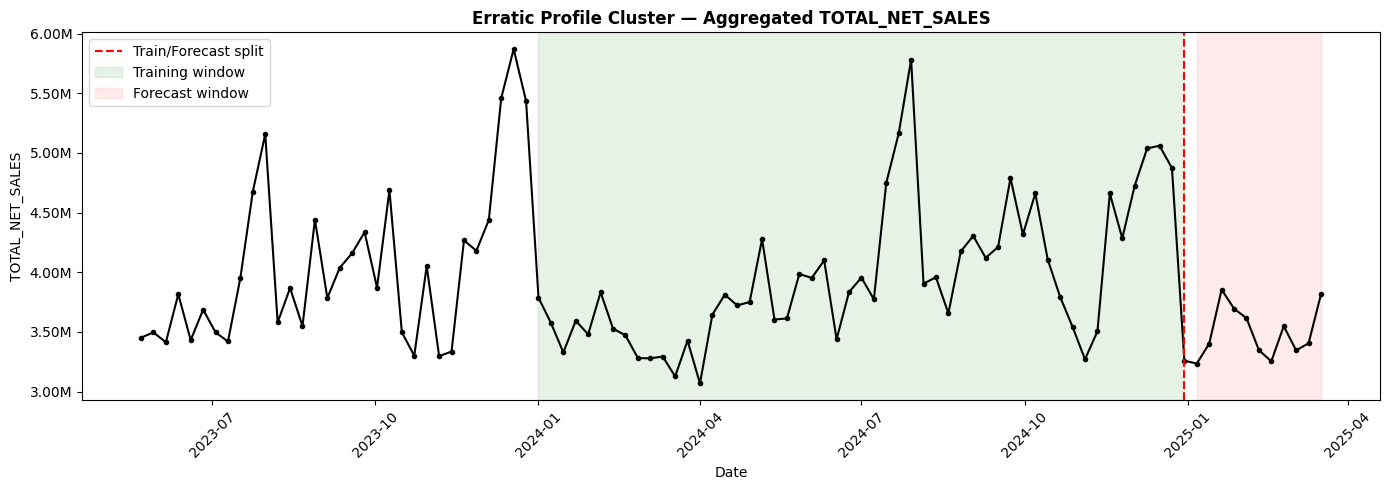

Erratic series count: 12
Series IDs: [np.int64(9), np.int64(15), np.int64(16), np.int64(17), np.int64(20), np.int64(24), np.int64(25), np.int64(31), np.int64(36), np.int64(45), np.int64(47), np.int64(50)]


In [4]:
# Aggregate target across all erratic series
df_plot = df_erratic.groupby(date_var)[y].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_plot[date_var], df_plot[y], color='black', linewidth=1.5, marker='o', markersize=3)
ax.axvline(x=training_end_date, color='red', linestyle='--', linewidth=1.5, label='Train/Forecast split')
ax.axvspan(training_start_date, training_end_date, color='green', alpha=0.10, label='Training window')
ax.axvspan(forecast_start_date, forecast_end_date, color='red', alpha=0.08, label='Forecast window')
ax.set_title(f'Erratic Profile Cluster \u2014 Aggregated {y}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel(y)
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Erratic series count: {df_erratic[unique_id].nunique()}")
print(f"Series IDs: {sorted(df_erratic[unique_id].unique())}")

# 5. Moving Average Model Definitions

Three types of moving average forecasting:

1. **Simple Moving Average (SMA)**: Forecast = mean of last `w` observations
2. **Weighted Moving Average (WMA)**: Forecast = weighted mean with linearly increasing weights
3. **Exponential Moving Average (EMA)**: Uses exponential decay (`span` parameter)

In [5]:
def forecast_sma(series, window):
    """Simple Moving Average forecast: mean of last `window` values."""
    if len(series) < window:
        return series.mean()
    return series.iloc[-window:].mean()


def forecast_wma(series, window):
    """Weighted Moving Average forecast: linearly increasing weights."""
    if len(series) < window:
        w = np.arange(1, len(series) + 1, dtype=float)
        vals = series.values
    else:
        w = np.arange(1, window + 1, dtype=float)
        vals = series.iloc[-window:].values
    return np.average(vals, weights=w)


def forecast_ema(series, span):
    """Exponential Moving Average forecast: last EMA value."""
    ema = series.ewm(span=span, adjust=False).mean()
    return ema.iloc[-1]


print("\u2705 Moving average forecast functions defined.")

✅ Moving average forecast functions defined.


# 6. Rolling Evaluation (In-Sample)

For each evaluation date in the training window:
1. Use all data prior to that date as history
2. Generate a 1-step-ahead forecast using each MA model variant
3. Compare against the actual value

In [6]:
# Define evaluation dates within the training window
eval_dates = pd.date_range(start=training_start_date, end=training_end_date, freq=frequency)

# Keep only dates that exist in the data
available_dates = set(df_erratic[date_var].unique())
eval_dates = [d for d in eval_dates if d in available_dates]

print(f"Evaluation dates: {len(eval_dates)} dates")
print(f"  From: {eval_dates[0].date()} to {eval_dates[-1].date()}")

Evaluation dates: 53 dates
  From: 2024-01-01 to 2024-12-30


In [7]:
# Rolling evaluation
results = []

for eval_date in eval_dates:
    for sid in df_erratic[unique_id].unique():
        series_data = df_erratic[
            (df_erratic[unique_id] == sid) & (df_erratic[date_var] <= eval_date)
        ].sort_values(date_var)
        
        # Get actual value at eval_date
        actual_row = series_data[series_data[date_var] == eval_date]
        if actual_row.empty:
            continue
        actual_value = actual_row[y].values[0]
        
        # History is everything before eval_date
        history = series_data[series_data[date_var] < eval_date][y]
        if len(history) < 2:
            continue
        
        row_base = {
            unique_id: sid,
            date_var: eval_date,
            'actual': actual_value,
        }
        
        # SMA forecasts
        for w in MA_WINDOWS:
            row_base[f'SMA_{w}'] = forecast_sma(history, w)
        
        # WMA forecasts
        for w in MA_WINDOWS:
            row_base[f'WMA_{w}'] = forecast_wma(history, w)
        
        # EMA forecasts
        for span in EMA_SPANS:
            row_base[f'EMA_{span}'] = forecast_ema(history, span)
        
        results.append(row_base)

df_results = pd.DataFrame(results)
print(f"\u2705 Generated {len(df_results)} forecast rows across {df_results[unique_id].nunique()} series")
df_results.head()

✅ Generated 636 forecast rows across 12 series


,STORE_LOCATION_ID,ds,actual,SMA_3,SMA_4,SMA_6,SMA_8,SMA_12,WMA_3,WMA_4,WMA_6,WMA_8,WMA_12,EMA_3,EMA_4,EMA_6,EMA_8,EMA_12
0,9,2024-01-01,333679.812685,525277.040821,499189.010805,461959.085176,430507.892268,407547.637351,522117.220025,512945.936337,489972.753187,467363.977620,437397.033115,502664.554377,492249.123614,471231.156772,454595.702556,432119.257503
1,15,2024-01-01,326905.586644,425552.260104,415374.012681,378671.008785,329634.238898,313663.052881,430881.366015,424678.424681,403514.201542,376840.401081,343600.393734,419436.863000,405944.728939,382152.643284,364575.598433,342255.295450
2,16,2024-01-01,363135.133487,546926.398766,508359.425701,468341.440048,420134.029441,399206.113005,546691.414903,531358.619222,500613.204040,472142.586709,434540.566733,521375.457758,506529.509337,479333.194889,459414.048958,434713.297886
3,17,2024-01-01,338917.486167,478060.323707,455307.508285,419413.403357,389096.481772,367013.954652,476393.203849,467958.925623,446422.832737,424541.085920,395541.455215,460096.257442,449269.979493,428708.912189,412901.057223,392001.145035
4,20,2024-01-01,287040.600399,408111.035064,384555.465244,364063.438895,333143.411395,311950.583160,414330.265718,402420.345528,382951.399703,365254.938303,339189.810130,402089.559861,389780.305099,369450.256897,354673.763555,336082.826452


# 7. Compute Metrics

In [8]:
def compute_metrics(df_results, actual_col='actual'):
    """Compute MAE, RMSE, WMAPE for all forecast columns."""
    pred_cols = [c for c in df_results.columns if c.startswith(('SMA_', 'WMA_', 'EMA_'))]
    
    metrics_list = []
    actuals = df_results[actual_col].values.astype(float)
    
    for col in pred_cols:
        preds = df_results[col].values.astype(float)
        
        # Remove NaN pairs
        mask = ~(np.isnan(actuals) | np.isnan(preds))
        a = actuals[mask]
        p = preds[mask]
        
        if len(a) == 0:
            continue
        
        mae = mean_absolute_error(a, p)
        rmse = np.sqrt(mean_squared_error(a, p))
        wmape = np.abs(a - p).sum() / np.abs(a).sum() if np.abs(a).sum() > 0 else np.nan
        
        # Parse model type and window
        parts = col.split('_')
        model_type = parts[0]
        window = int(parts[1])
        
        metrics_list.append({
            'model': col,
            'type': model_type,
            'window': window,
            'MAE': mae,
            'RMSE': rmse,
            'WMAPE': wmape,
            'n_predictions': len(a),
        })
    
    return pd.DataFrame(metrics_list).sort_values('MAE')


metrics_df = compute_metrics(df_results)

print("=" * 60)
print("IN-SAMPLE MODEL PERFORMANCE (sorted by MAE)")
print("=" * 60)
display(metrics_df)

best_model = metrics_df.iloc[0]['model']
best_type = metrics_df.iloc[0]['type']
best_window = int(metrics_df.iloc[0]['window'])
print(f"\n\u2705 Best model: {best_model} (MAE={metrics_df.iloc[0]['MAE']:,.2f}, WMAPE={metrics_df.iloc[0]['WMAPE']:.4f})")

IN-SAMPLE MODEL PERFORMANCE (sorted by MAE)


,model,type,window,MAE,RMSE,WMAPE,n_predictions
10,EMA_3,EMA,3,42032.458585,55151.753892,0.127651,636
11,EMA_4,EMA,4,42795.011071,55513.248204,0.129967,636
5,WMA_3,WMA,3,43250.317994,57312.872984,0.131350,636
12,EMA_6,EMA,6,43778.764278,55730.438292,0.132955,636
13,EMA_8,EMA,8,44264.228043,55766.801645,0.134429,636
6,WMA_4,WMA,4,44459.837636,58415.356472,0.135023,636
14,EMA_12,EMA,12,44540.449926,55793.563040,0.135268,636
9,WMA_12,WMA,12,45968.247155,57237.445320,0.139604,636
7,WMA_6,WMA,6,46087.044218,59330.427752,0.139965,636
8,WMA_8,WMA,8,46276.149350,58809.736446,0.140539,636



✅ Best model: EMA_3 (MAE=42,032.46, WMAPE=0.1277)


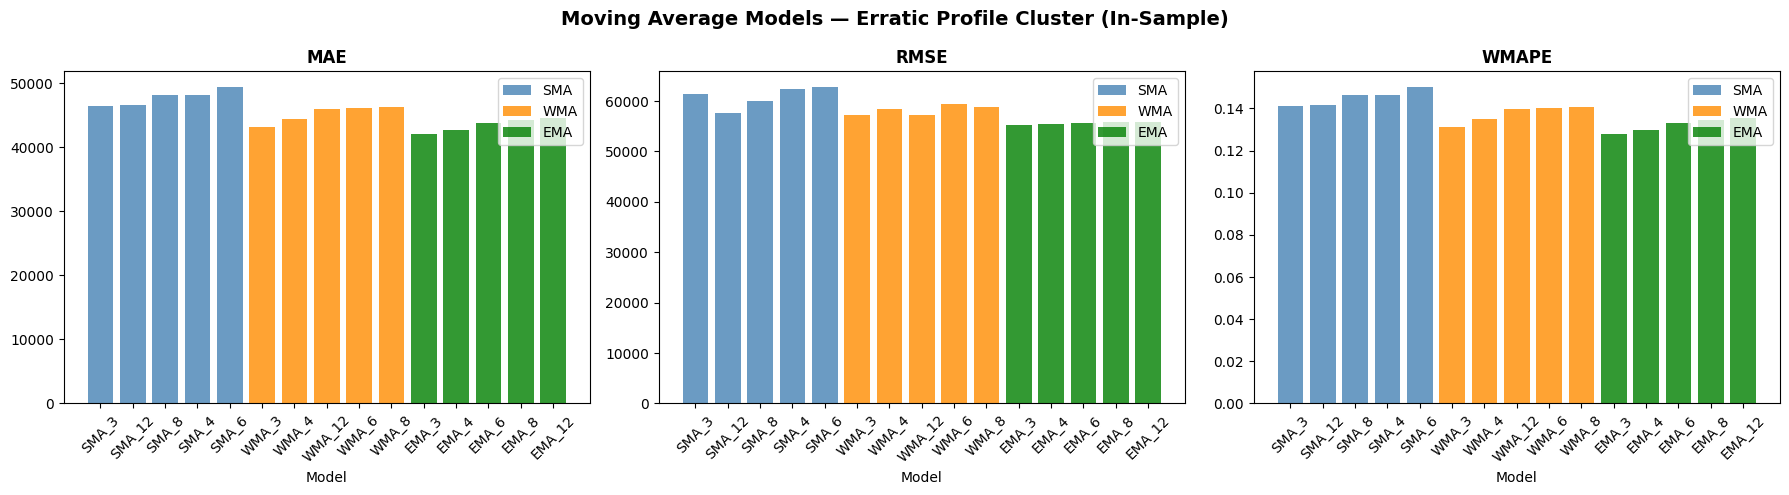

In [9]:
# Metrics comparison chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'WMAPE']):
    for model_type, color in [('SMA', 'steelblue'), ('WMA', 'darkorange'), ('EMA', 'green')]:
        subset = metrics_df[metrics_df['type'] == model_type]
        ax.bar(subset['model'], subset[metric], color=color, alpha=0.8, label=model_type)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Moving Average Models \u2014 Erratic Profile Cluster (In-Sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Per-Series Metrics

Compute metrics at the individual series level to see which erratic series benefit most from the best MA model.

In [10]:
# Per-series metrics using the best model
per_series_metrics = []

for sid in df_results[unique_id].unique():
    subset = df_results[df_results[unique_id] == sid]
    a = subset['actual'].values.astype(float)
    p = subset[best_model].values.astype(float)
    
    mask = ~(np.isnan(a) | np.isnan(p))
    a, p = a[mask], p[mask]
    
    if len(a) == 0:
        continue
    
    mae = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    wmape = np.abs(a - p).sum() / np.abs(a).sum() if np.abs(a).sum() > 0 else np.nan
    
    per_series_metrics.append({
        unique_id: sid,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
        'n_obs': len(a),
    })

df_per_series = pd.DataFrame(per_series_metrics).sort_values('MAE', ascending=False)

print(f"Per-series metrics using best model: {best_model}")
print(f"  Median MAE:   {df_per_series['MAE'].median():,.2f}")
print(f"  Mean WMAPE:   {df_per_series['WMAPE'].mean():.4f}")
print(f"  Worst series: {df_per_series.iloc[0][unique_id]} (MAE={df_per_series.iloc[0]['MAE']:,.2f})")
print(f"  Best series:  {df_per_series.iloc[-1][unique_id]} (MAE={df_per_series.iloc[-1]['MAE']:,.2f})")
display(df_per_series)

Per-series metrics using best model: EMA_3
  Median MAE:   41,082.71
  Mean WMAPE:   0.1292
  Worst series: 16.0 (MAE=47,932.32)
  Best series:  15.0 (MAE=36,987.19)


,STORE_LOCATION_ID,MAE,RMSE,WMAPE,n_obs
2,16,47932.320620,60104.492008,0.123255,53
9,45,46921.104068,60176.966520,0.164800,53
8,36,45603.940257,59731.409925,0.143805,53
5,24,44403.519076,57558.691060,0.147819,53
4,20,41617.967633,53278.564489,0.145009,53
10,47,41147.211604,55023.296489,0.113220,53
0,9,41018.204760,55283.910179,0.110834,53
11,50,40473.545695,54149.676597,0.136524,53
6,25,40078.749357,52875.293562,0.107231,53
7,31,39902.539348,54719.235563,0.113772,53


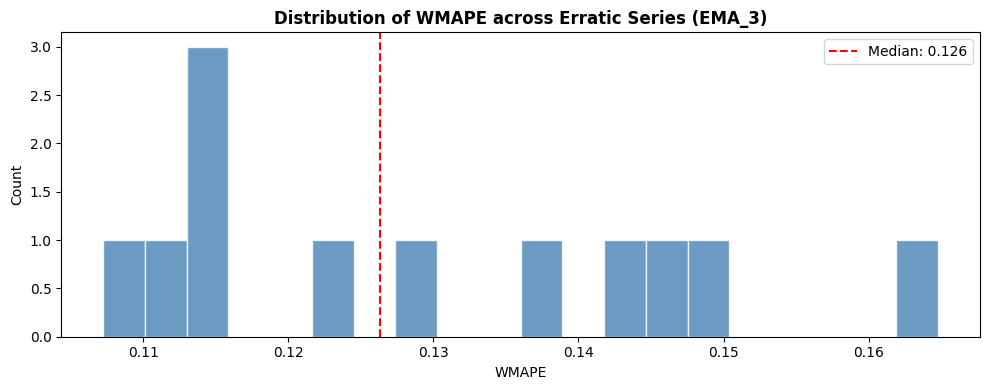

In [11]:
# WMAPE distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_per_series['WMAPE'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df_per_series['WMAPE'].median(), color='red', linestyle='--',
           label=f"Median: {df_per_series['WMAPE'].median():.3f}")
ax.set_title(f'Distribution of WMAPE across Erratic Series ({best_model})', fontsize=12, fontweight='bold')
ax.set_xlabel('WMAPE')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# 9. Out-of-Sample Forecast

Generate multi-step forecasts for the OOS period using the best moving average model with recursive prediction.

In [12]:
# Generate OOS forecasts using the best model (recursive multi-step)
print(f"Best model: {best_model} (type={best_type}, window={best_window})")

oos_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=frequency)
print(f"OOS dates: {len(oos_dates)} weeks from {oos_dates[0].date()} to {oos_dates[-1].date()}")

oos_forecasts = []

for sid in df_erratic[unique_id].unique():
    # Full history up to training_end_date
    series_hist = df_erratic[
        (df_erratic[unique_id] == sid) & (df_erratic[date_var] <= training_end_date)
    ].sort_values(date_var)[y].values.tolist()
    
    if len(series_hist) < 2:
        continue
    
    for oos_date in oos_dates:
        history = pd.Series(series_hist)
        
        if best_type == 'SMA':
            pred = forecast_sma(history, best_window)
        elif best_type == 'WMA':
            pred = forecast_wma(history, best_window)
        elif best_type == 'EMA':
            pred = forecast_ema(history, best_window)
        else:
            pred = forecast_sma(history, best_window)
        
        oos_forecasts.append({
            unique_id: sid,
            date_var: oos_date,
            'y_hat_ma': pred,
        })
        
        # Append prediction for recursive multi-step
        series_hist.append(pred)

df_oos = pd.DataFrame(oos_forecasts)
print(f"\n\u2705 OOS forecasts: {len(df_oos)} rows for {df_oos[unique_id].nunique()} series")
print(f"OOS period: {df_oos[date_var].min().date()} to {df_oos[date_var].max().date()}")
df_oos.head()

Best model: EMA_3 (type=EMA, window=3)
OOS dates: 11 weeks from 2025-01-06 to 2025-03-17

✅ OOS forecasts: 132 rows for 12 series
OOS period: 2025-01-06 to 2025-03-17


,STORE_LOCATION_ID,ds,y_hat_ma
0,9,2025-01-06,357101.554411
1,9,2025-01-13,357101.554411
2,9,2025-01-20,357101.554411
3,9,2025-01-27,357101.554411
4,9,2025-02-03,357101.554411


In [13]:
# OOS Metrics (if actuals available in the data)
df_oos_eval = df_oos.merge(
    df_erratic[[unique_id, date_var, y]],
    on=[unique_id, date_var],
    how='left'
)

df_oos_eval_valid = df_oos_eval.dropna(subset=[y])

if len(df_oos_eval_valid) > 0:
    actuals = df_oos_eval_valid[y].values.astype(float)
    preds = df_oos_eval_valid['y_hat_ma'].values.astype(float)
    
    oos_mae = mean_absolute_error(actuals, preds)
    oos_rmse = np.sqrt(mean_squared_error(actuals, preds))
    oos_wmape = np.abs(actuals - preds).sum() / np.abs(actuals).sum()
    
    print("=" * 60)
    print(f"OUT-OF-SAMPLE METRICS ({best_model})")
    print("=" * 60)
    print(f"  MAE:          {oos_mae:>12,.2f}")
    print(f"  RMSE:         {oos_rmse:>12,.2f}")
    print(f"  WMAPE:        {oos_wmape:>12.4f}")
    print(f"  N predictions: {len(df_oos_eval_valid)}")
else:
    print("No actuals available in the OOS period. Metrics cannot be computed.")
    oos_mae = oos_rmse = oos_wmape = None

OUT-OF-SAMPLE METRICS (EMA_3)
  MAE:             49,938.44
  RMSE:            59,382.13
  WMAPE:              0.1712
  N predictions: 132


# 10. Forecast Visualization

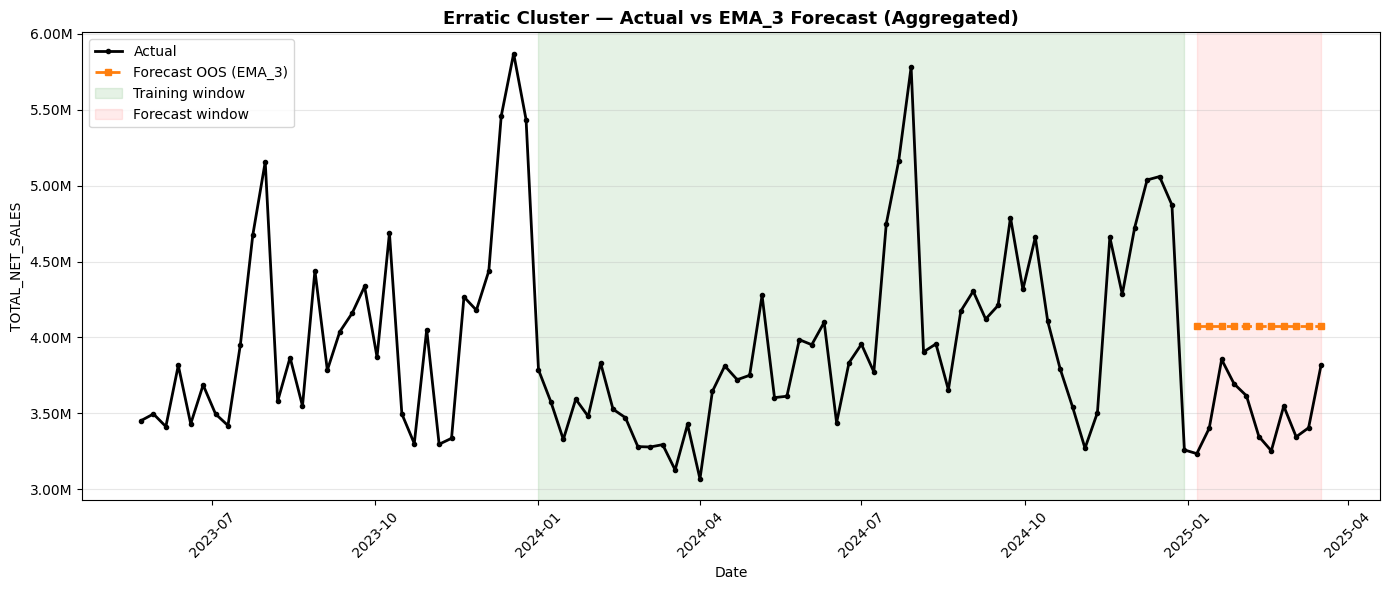

In [14]:
# Aggregate forecast vs actuals
actual_agg = df_erratic.groupby(date_var)[y].sum().reset_index().sort_values(date_var)
oos_agg = df_oos.groupby(date_var)['y_hat_ma'].sum().reset_index().sort_values(date_var)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actual_agg[date_var], actual_agg[y], color='black', linewidth=2, marker='o', markersize=3, label='Actual', zorder=3)
ax.plot(oos_agg[date_var], oos_agg['y_hat_ma'], color='tab:orange', linewidth=2, linestyle='--', marker='s',
        markersize=4, label=f'Forecast OOS ({best_model})', zorder=4)
ax.axvspan(training_start_date, training_end_date, color='green', alpha=0.10, label='Training window')
ax.axvspan(forecast_start_date, forecast_end_date, color='red', alpha=0.08, label='Forecast window')
ax.set_title(f'Erratic Cluster \u2014 Actual vs {best_model} Forecast (Aggregated)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel(y)
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

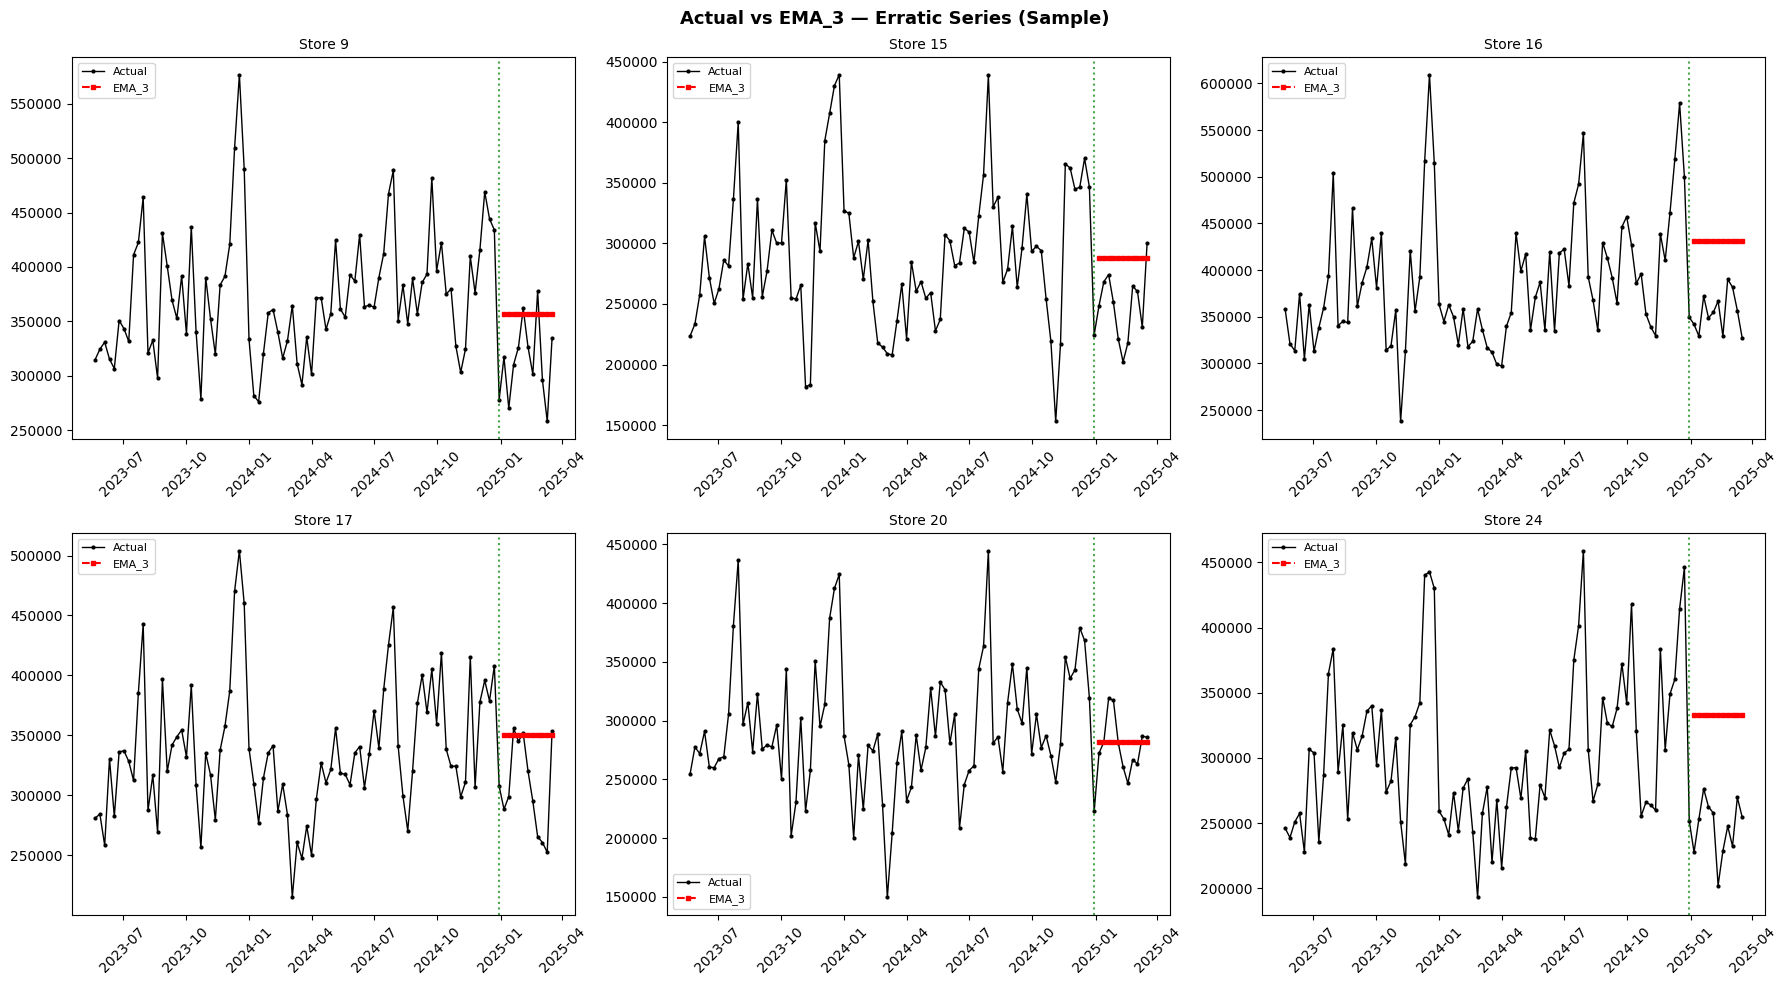

In [15]:
# Individual series plots (sample)
sample_ids = df_erratic[unique_id].unique()[:6]
n_plots = min(6, len(sample_ids))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sid in enumerate(sample_ids[:n_plots]):
    ax = axes[i]
    # Actuals
    act = df_erratic[df_erratic[unique_id] == sid].sort_values(date_var)
    ax.plot(act[date_var], act[y], 'k-o', markersize=2, linewidth=1, label='Actual')
    # OOS forecast
    fcst = df_oos[df_oos[unique_id] == sid].sort_values(date_var)
    ax.plot(fcst[date_var], fcst['y_hat_ma'], 'r--s', markersize=3, linewidth=1.5, label=f'{best_model}')
    ax.axvline(x=training_end_date, color='green', linestyle=':', alpha=0.7)
    ax.set_title(f'Store {sid}', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

# Hide unused axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Actual vs {best_model} \u2014 Erratic Series (Sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 11. Final Summary

In [16]:
print("=" * 70)
print("MOVING AVERAGE MODELS \u2014 ERRATIC PROFILE CLUSTER \u2014 FINAL SUMMARY")
print("=" * 70)

print(f"\nSeries count: {df_erratic[unique_id].nunique()}")
print(f"Training window:  {training_start_date.date()} to {training_end_date.date()}")
print(f"Forecast window:  {forecast_start_date.date()} to {forecast_end_date.date()}")
print(f"Frequency: {frequency}")

print(f"\n--- Best Model ---")
print(f"  Model: {best_model}")
print(f"  Type:  {best_type}")
print(f"  Window/Span: {best_window}")

print(f"\n--- In-Sample Metrics (Rolling Evaluation) ---")
print(f"  MAE:   {metrics_df.iloc[0]['MAE']:>12,.2f}")
print(f"  RMSE:  {metrics_df.iloc[0]['RMSE']:>12,.2f}")
print(f"  WMAPE: {metrics_df.iloc[0]['WMAPE']:>12.4f}")

if oos_mae is not None:
    print(f"\n--- Out-of-Sample Metrics ---")
    print(f"  MAE:   {oos_mae:>12,.2f}")
    print(f"  RMSE:  {oos_rmse:>12,.2f}")
    print(f"  WMAPE: {oos_wmape:>12.4f}")

print(f"\n--- All Models Ranked by {selection_metric} ---")
print(metrics_df[['model', 'type', 'window', 'MAE', 'RMSE', 'WMAPE']].to_string(index=False))

print(f"\n{'=' * 70}")
print("\u2705 Notebook complete!")

MOVING AVERAGE MODELS — ERRATIC PROFILE CLUSTER — FINAL SUMMARY

Series count: 12
Training window:  2024-01-01 to 2024-12-30
Forecast window:  2025-01-06 to 2025-03-17
Frequency: W-MON

--- Best Model ---
  Model: EMA_3
  Type:  EMA
  Window/Span: 3

--- In-Sample Metrics (Rolling Evaluation) ---
  MAE:      42,032.46
  RMSE:     55,151.75
  WMAPE:       0.1277

--- Out-of-Sample Metrics ---
  MAE:      49,938.44
  RMSE:     59,382.13
  WMAPE:       0.1712

--- All Models Ranked by MAE ---
 model type  window          MAE         RMSE    WMAPE
 EMA_3  EMA       3 42032.458585 55151.753892 0.127651
 EMA_4  EMA       4 42795.011071 55513.248204 0.129967
 WMA_3  WMA       3 43250.317994 57312.872984 0.131350
 EMA_6  EMA       6 43778.764278 55730.438292 0.132955
 EMA_8  EMA       8 44264.228043 55766.801645 0.134429
 WMA_4  WMA       4 44459.837636 58415.356472 0.135023
EMA_12  EMA      12 44540.449926 55793.563040 0.135268
WMA_12  WMA      12 45968.247155 57237.445320 0.139604
 WMA_6  WM

# 12. Save Forecast Results

In [17]:
# Save OOS forecast for erratic cluster
output_path = f"{root_path}/data/{LOCAL_FOLDER}/forecast_cluster_erratic_ma.csv"
df_oos.to_csv(output_path, index=False)
print(f"\u2705 Saved OOS forecast: {output_path} ({len(df_oos)} rows)")

# Save metrics summary
metrics_path = f"{root_path}/data/{LOCAL_FOLDER}/metrics_erratic_ma.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"\u2705 Saved metrics: {metrics_path}")

✅ Saved OOS forecast: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent/data/supermarket_net_sales/forecast_cluster_erratic_ma.csv (132 rows)
✅ Saved metrics: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent/data/supermarket_net_sales/metrics_erratic_ma.csv
